# 03a_Neighbour Coherence Diagnostic

## Objective
Assess whether neighbour-based drift monitoring is defensible in this sensor network:

- "Are neighbouring sensors similar enough, across time and across metrics, for neighbour-aware residual modelling to be defensible?"

This notebook is diagnostic only. It does not produce final drift score/flag/type.

Required outputs (saved under `/data/`):
- `metric_neighbour_coherence.csv`
- `sensor_neighbour_coverage.csv`
- `hourly_sensor_panel.parquet`
- `validated_neighbour_pairs.csv`

Optional:
- `selected_neighbour_diagnostics.csv`

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', 200)

root = Path('..')
data_dir = root / 'data'
outputs = data_dir

required_files = {
    'merged': data_dir / 'merged_sensor_metadata.csv',
    'neighbours': data_dir / 'neighbours.json'
}

for name, path in required_files.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing required input file: {name} at {path.resolve()}")

print('All input files found.')

All input files found.


In [13]:
# 1. Load and validate inputs
raw = pd.read_csv(required_files['merged'])
with open(required_files['neighbours'], 'r') as f:
    neighbour_map_raw = json.load(f)

print('Raw dataset rows:', len(raw))
print('Neighbour map entries:', len(neighbour_map_raw))

# Required columns
timestamp_col = 'timestamp_utc'
sensor_col = 'ateccid'

for col in [timestamp_col, sensor_col]:
    if col not in raw.columns:
        raise ValueError(f"Missing required column in main dataset: {col}")

# Validate neighbour mapping structure
if not isinstance(neighbour_map_raw, dict):
    raise ValueError('neighbours.json must encode a dict mapping sensor -> neighbour list')

neighbour_map = {}
for sensor, neighbours in neighbour_map_raw.items():
    if not isinstance(neighbours, (list, tuple)):
        raise ValueError(f"Neighbours for sensor {sensor} must be a list")
    neighbour_map[str(sensor).strip()] = [str(n).strip() for n in neighbours if str(n).strip()]

# Numeric columns for candidate metrics
numeric_cols = raw.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric columns:', numeric_cols)

exclude_cols = [
    'index', 'row_id', 'X', 'Y', 'x', 'y',
    'Bearing', 'bearing', 'Bearing  (°)', 'Rotation', 'Rotation (°)', 'Height m', 'height', 'height_m',
    'id', 'sensor_type', 'Device Location'
]

candidate_metrics = [c for c in numeric_cols if c not in exclude_cols]
if not candidate_metrics:
    raise ValueError('No numeric time-varying metrics found after exclusions')

print('Candidate metrics for coherence:', candidate_metrics)

# Optional static column filtering: keep only time-varying metrics (estimated by no constant)
var_metrics = []
for c in candidate_metrics:
    if raw[c].nunique(dropna=True) > 1:
        var_metrics.append(c)
    else:
        print(f'Excluding constant metric: {c}')

if not var_metrics:
    raise ValueError('No variable metrics available for coherence analysis')

metrics = var_metrics
print('Metrics used:', metrics)

# Keep cleaned dataframe with relevant columns
raw[sensor_col] = raw[sensor_col].astype(str).str.strip()
raw[timestamp_col] = pd.to_datetime(raw[timestamp_col], errors='coerce', utc=True)
if raw[timestamp_col].isna().any():
    raw[sensor_col] = raw[sensor_col].astype(str).str.strip()
    raw[timestamp_col] = pd.to_datetime(raw[timestamp_col], errors='coerce', utc=True)

    if raw[timestamp_col].isna().any():
        n_invalid = raw[timestamp_col].isna().sum()
        print(f"Found {n_invalid} invalid timestamps in {timestamp_col}; dropping those rows.")
        raw = raw.loc[~raw[timestamp_col].isna()].copy()

    if raw.empty:
        raise ValueError('All rows dropped due invalid timestamps in timestamp_utc')

    raw_clean = raw[[timestamp_col, sensor_col] + metrics].copy()
    print('raw_clean dimensions', raw_clean.shape)

raw_clean = raw[[timestamp_col, sensor_col] + metrics].copy()
print('raw_clean dimensions', raw_clean.shape)
print('raw_clean head', raw_clean.head())


Raw dataset rows: 1048575
Neighbour map entries: 33
Numeric columns: ['index', 'capacity_people', 'min_occupant', 'max_occupant', 'total_occupant', 'tvoc', 'co2', 'temp', 'pressure', 'lux', 'snd', 'combined_occupancy', 'humid', 'bearing', 'aqi1', 'aqi2', 'aqi3', 'blue_relative', 'clear_relative', 'green_relative', 'no2', 'o3', 'red_relative', 'voc_resistance', 'avg_occupant', 'occupancy1', 'occupancy2', 'Device Location', 'X', 'Y', 'Bearing  (°)', 'Rotation (°)', 'Height (m)']
Candidate metrics for coherence: ['capacity_people', 'min_occupant', 'max_occupant', 'total_occupant', 'tvoc', 'co2', 'temp', 'pressure', 'lux', 'snd', 'combined_occupancy', 'humid', 'aqi1', 'aqi2', 'aqi3', 'blue_relative', 'clear_relative', 'green_relative', 'no2', 'o3', 'red_relative', 'voc_resistance', 'avg_occupant', 'occupancy1', 'occupancy2', 'Height (m)']
Excluding constant metric: Height (m)
Metrics used: ['capacity_people', 'min_occupant', 'max_occupant', 'total_occupant', 'tvoc', 'co2', 'temp', 'pressur

In [14]:
# 2. Build clean hourly panel
raw_clean = raw_clean.sort_values([sensor_col, timestamp_col])

# We'll do per-sensor resampling to 1h mean for continuous metrics
panel = (
    raw_clean
    .set_index(timestamp_col)
    .groupby(sensor_col)[metrics]
    .resample('1h')
    .mean()
    .reset_index()
)

print('Hourly panel rows:', len(panel))
print('Hourly panel sample:')
panel.head()

# Persist panel for downstream
hourly_sensor_panel_path = outputs / 'hourly_sensor_panel.csv'
panel.to_csv(hourly_sensor_panel_path, index=False)
print('Saved:', hourly_sensor_panel_path)

Hourly panel rows: 25344
Hourly panel sample:
Saved: ../data/hourly_sensor_panel.csv


In [15]:
# 3. Build neighbour comparison structure
# pivot panel for rapid cross-sensor operations per metric
sensor_list = sorted(panel[sensor_col].unique())
panel_presence = (
    panel.assign(has_data=panel[metrics].notna().any(axis=1))
    .pivot(index=timestamp_col, columns=sensor_col, values='has_data')
    .fillna(False)
)

coverage_records = []

# This is cost O(timestamps * sensors * neighbours) - manageable for <50 sensors
for ts, row in panel_presence.iterrows():
    for sensor in sensor_list:
        expected = len(neighbour_map.get(sensor, []))
        neighbourhood = [n for n in neighbour_map.get(sensor, []) if n in sensor_list]
        observed = int(row.loc[neighbourhood].sum() if neighbourhood else 0)
        ratio = observed / expected if expected > 0 else np.nan

        coverage_records.append({
            'timestamputc': ts,
            'sensor': sensor,
            'expected_neighbours': expected,
            'observed_neighbours': observed,
            'neighbour_coverage_ratio': ratio
        })

coverage_df = pd.DataFrame(coverage_records)
coverage_agg = coverage_df.groupby('sensor').agg(
    expected_neighbours=('expected_neighbours', 'mean'),
    observed_neighbours=('observed_neighbours', 'mean'),
    mean_coverage=('neighbour_coverage_ratio', 'mean'),
    p50_coverage=('neighbour_coverage_ratio', 'median')
).reset_index()

sensor_neighbour_coverage_path = outputs / 'sensor_neighbour_coverage.csv'
coverage_df.to_csv(sensor_neighbour_coverage_path, index=False)
print('Saved coverage:', sensor_neighbour_coverage_path)

# validated neighbour pairs
pairs = []
for sensor, neighs in neighbour_map.items():
    for neigh in neighs:
        if sensor in sensor_list and neigh in sensor_list:
            pairs.append({'sensor': sensor, 'neighbour': neigh})

pairs_df = pd.DataFrame(pairs).drop_duplicates()
validated_neighbour_pairs_path = outputs / 'validated_neighbour_pairs.csv'
pairs_df.to_csv(validated_neighbour_pairs_path, index=False)
print('Saved validated neighbour pairs:', validated_neighbour_pairs_path)

Saved coverage: ../data/sensor_neighbour_coverage.csv
Saved validated neighbour pairs: ../data/validated_neighbour_pairs.csv


In [16]:
# 4. Quantify neighbour coherence
# Prepare metric-level summaries
metric_summaries = []

# Make time-indexed wide tables per metric
wide_metric = {}
for metric in metrics:
    wide_metric[metric] = panel.pivot(index=timestamp_col, columns=sensor_col, values=metric)

for metric in metrics:
    corr_records = []
    spearman_records = []
    residual_stats = []

    mdf = wide_metric[metric]

    for sensor in sensor_list:
        neighs = [n for n in neighbour_map.get(sensor, []) if n in sensor_list]
        if not neighs:
            continue

        sensor_ts = mdf[sensor]
        neighbour_mean = mdf[neighs].mean(axis=1)
        neighbour_median = mdf[neighs].median(axis=1)
        abs_resid = (sensor_ts - neighbour_median).abs()

        # correlation between sensor and each neighbour
        for n in neighs:
            neigh_ts = mdf[n]
            valid = sensor_ts.notna() & neigh_ts.notna()
            if valid.sum() < 20:
                continue

            corr_val = sensor_ts[valid].corr(neigh_ts[valid], method='pearson')
            spearman_val = sensor_ts[valid].corr(neigh_ts[valid], method='spearman')
            corr_records.append(corr_val)
            spearman_records.append(spearman_val)

        # ensure inf/-inf are treated as missing for summary stats
        abs_resid = abs_resid.replace([np.inf, -np.inf], np.nan)

        resid_mean = abs_resid.mean()
        resid_median = abs_resid.median()
        resid_std = abs_resid.std()

        rolling_std = abs_resid.rolling(window=24, min_periods=12).std().mean()
        rolling_mean = neighbour_mean.rolling(window=24, min_periods=12).mean().abs().replace(0, np.nan)
        rolling_cv = (rolling_std / rolling_mean).mean()

        residual_stats.append({
            'mean_abs_resid': resid_mean,
            'median_abs_resid': resid_median,
            'rolling_std': rolling_std,
            'rolling_cv': rolling_cv
        })

    metric_summary = {
        'metric': metric,
        'avg_pearson_corr': np.nanmean(corr_records) if corr_records else np.nan,
        'median_pearson_corr': np.nanmedian(corr_records) if corr_records else np.nan,
        'avg_spearman_corr': np.nanmean(spearman_records) if spearman_records else np.nan,
        'median_spearman_corr': np.nanmedian(spearman_records) if spearman_records else np.nan,
        'mean_abs_resid': np.nanmean([rs['mean_abs_resid'] for rs in residual_stats]) if residual_stats else np.nan,
        'median_abs_resid': np.nanmean([rs['median_abs_resid'] for rs in residual_stats]) if residual_stats else np.nan,
        'mean_rolling_cv': np.nanmean([rs['rolling_cv'] for rs in residual_stats if not np.isnan(rs['rolling_cv'])]) if residual_stats else np.nan,
        'count_pairs': len(corr_records)
    }
    metric_summaries.append(metric_summary)

coherence_df = pd.DataFrame(metric_summaries)
coherence_df['stability_rank'] = coherence_df['avg_pearson_corr'].rank(ascending=False, method='dense')

# Rule-based usability
threshold_good = 0.7
threshold_review = 0.5

def decide(row):
    if pd.isna(row['avg_pearson_corr']):
        return 'no'
    if row['avg_pearson_corr'] >= threshold_good and row['mean_abs_resid'] < 0.2 * row['mean_abs_resid'] if row['mean_abs_resid']>0 else True:
        return 'yes'
    if row['avg_pearson_corr'] >= threshold_review:
        return 'review'
    return 'no'

coherence_df['usable_for_neighbour_monitoring'] = coherence_df['avg_pearson_corr'].apply(
    lambda x: 'yes' if x >= threshold_good else ('review' if x >= threshold_review else 'no')
)

metric_neighbour_coherence_path = outputs / 'metric_neighbour_coherence.csv'
coherence_df.to_csv(metric_neighbour_coherence_path, index=False)
print('Saved metric coherence:', metric_neighbour_coherence_path)

/Users/mac/miniconda3/envs/beringar-env/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/mac/miniconda3/envs/beringar-env/lib/python3.13/site-packages/pandas/core/nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Users/mac/miniconda3/envs/beringar-env/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/mac/miniconda3/envs/beringar-env/lib/python3.13/site-packages/pandas/core/nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Users/mac/miniconda3/envs/beringar-env/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/mac/mi

Saved metric coherence: ../data/metric_neighbour_coherence.csv


In [17]:
# optional selected diagnostics
selected_diagnostics = []
sampled_sensors = list(coverage_agg.sort_values('mean_coverage', ascending=False).head(3)['sensor'])
sampled_sensors += list(coverage_agg.sort_values('mean_coverage', ascending=True).head(3)['sensor'])
for sensor in set(sampled_sensors):
    for metric in metrics[:4]:
        if sensor not in wide_metric[metric].columns:
            continue
        neighs = [n for n in neighbour_map.get(sensor, []) if n in sensor_list]
        selected_diagnostics.append({
            'sensor': sensor,
            'metric': metric,
            'neighbour_count': len(neighs),
            'mean_coverage': coverage_agg.loc[coverage_agg.sensor == sensor, 'mean_coverage'].values[0]
        })
selected_diagnostics_df = pd.DataFrame(selected_diagnostics)
selected_diagnostics_df.to_csv(outputs / 'selected_neighbour_diagnostics.csv', index=False)
print('Saved selected diagnostics')

Saved selected diagnostics


Chosen metrics for diagnostics: ['co2', 'temp', 'pressure', 'lux', 'snd', 'combined_occupancy', 'humid']


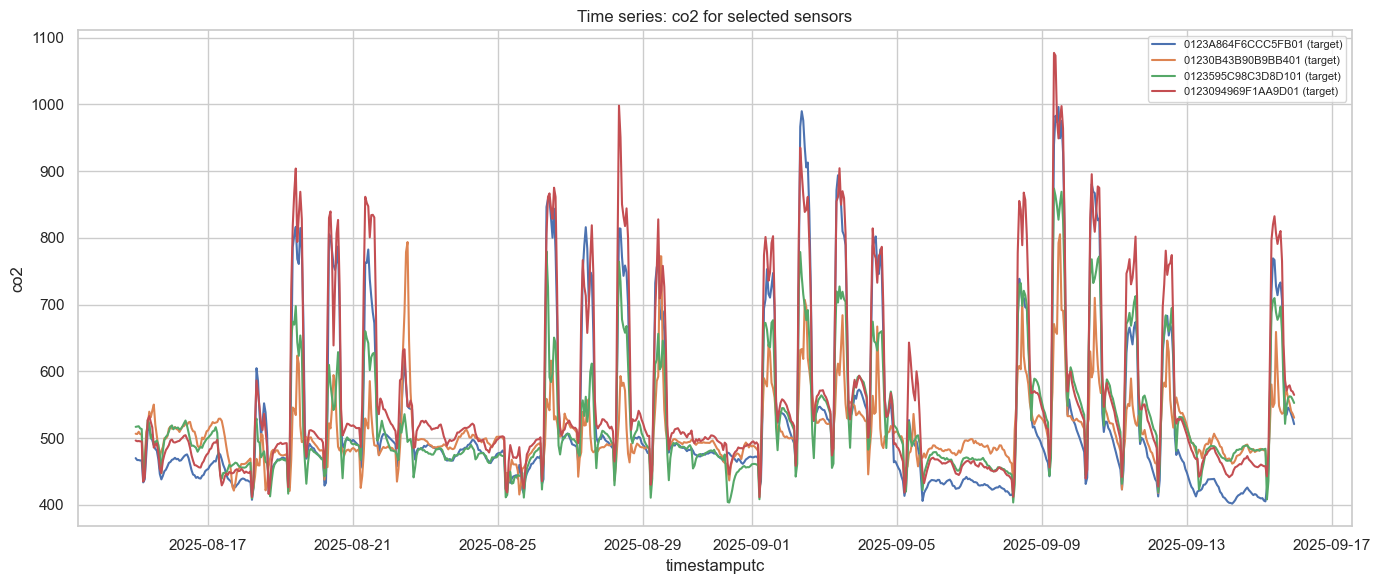

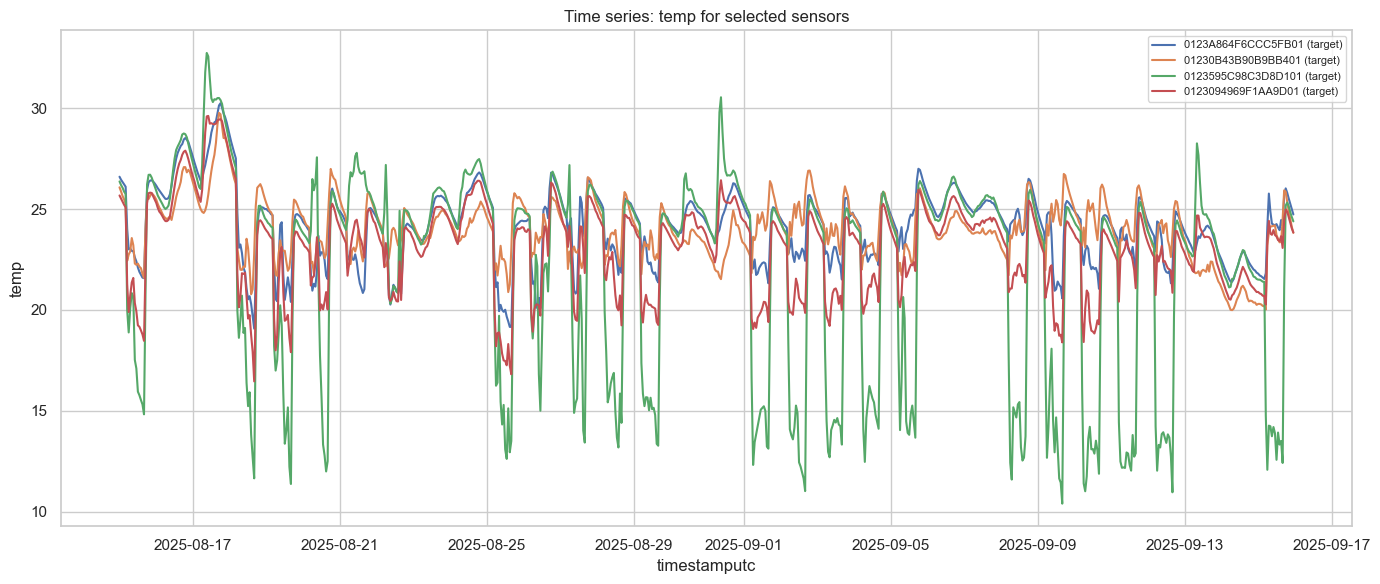

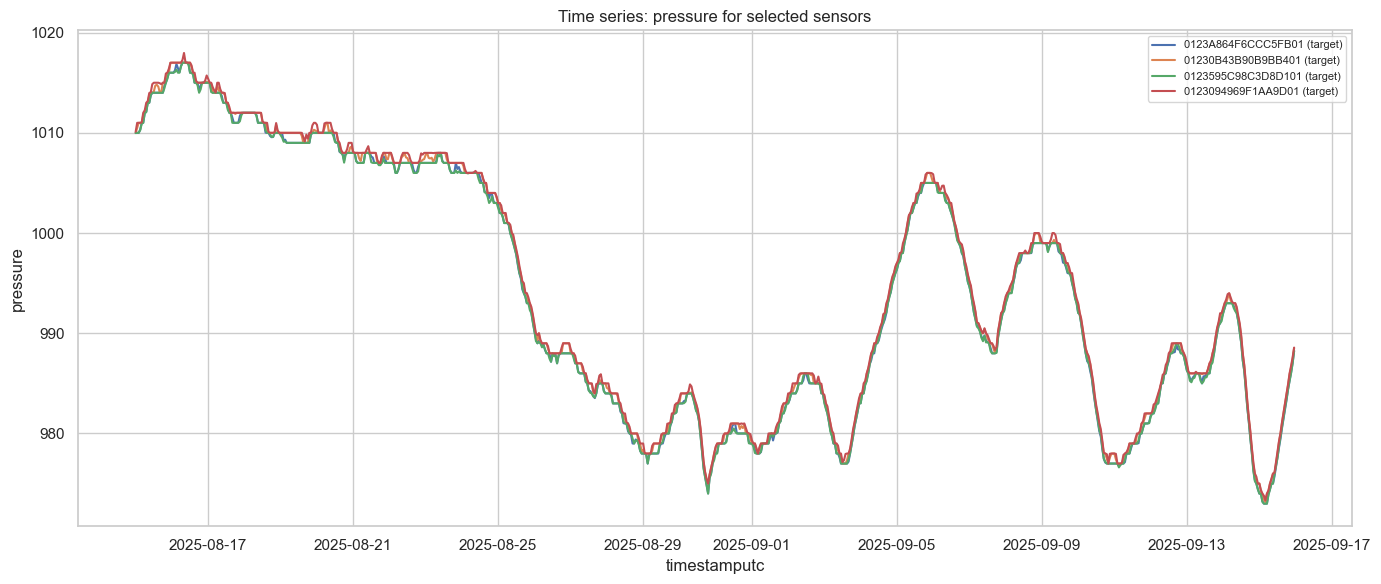

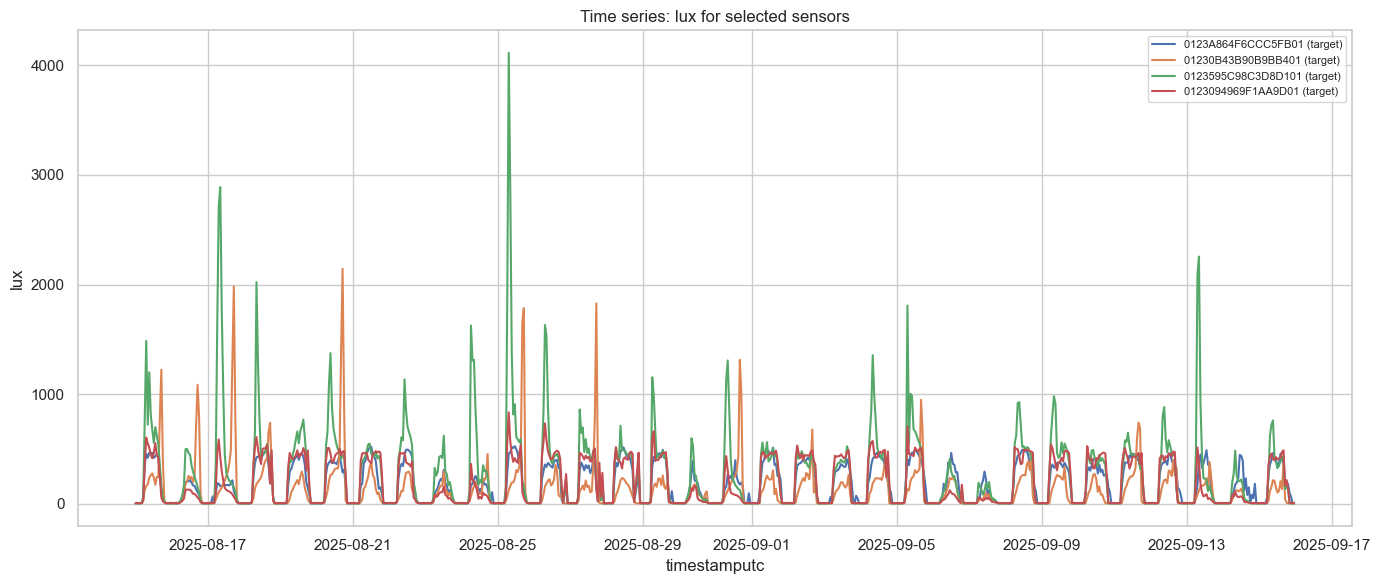

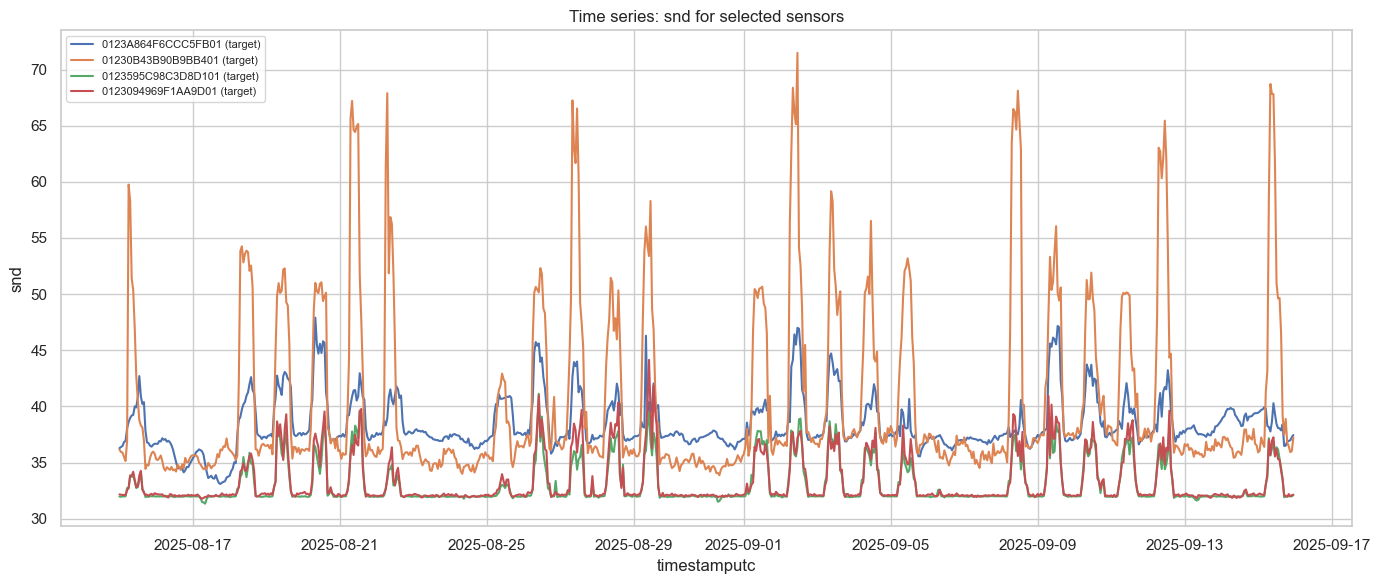

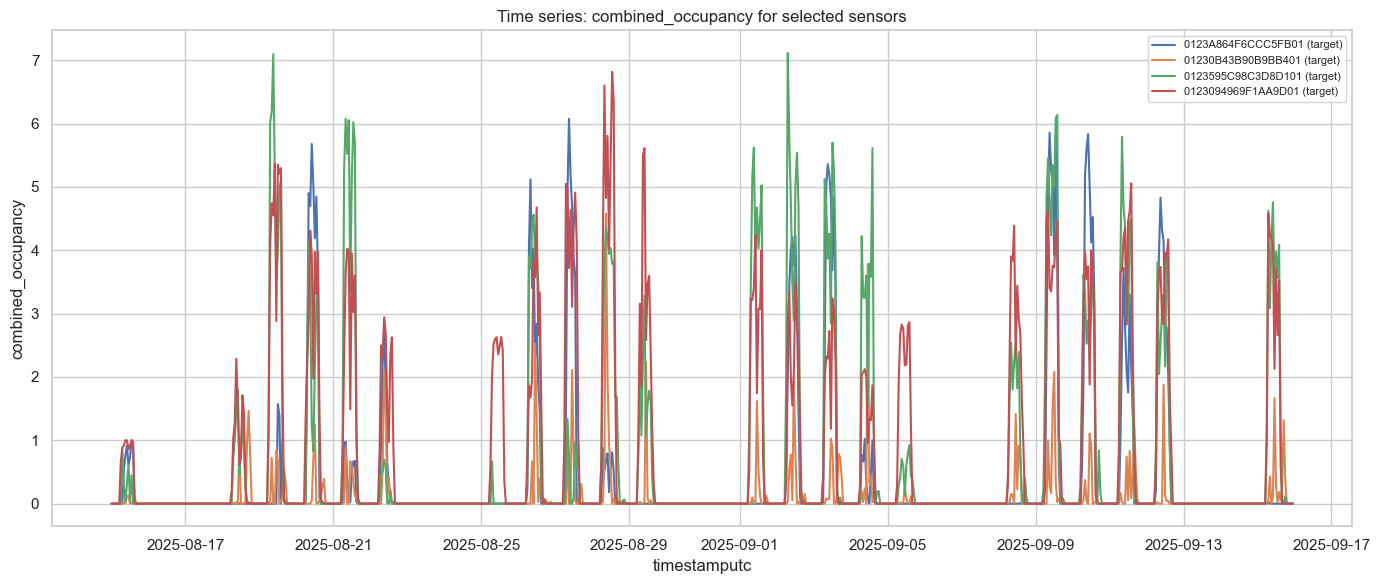

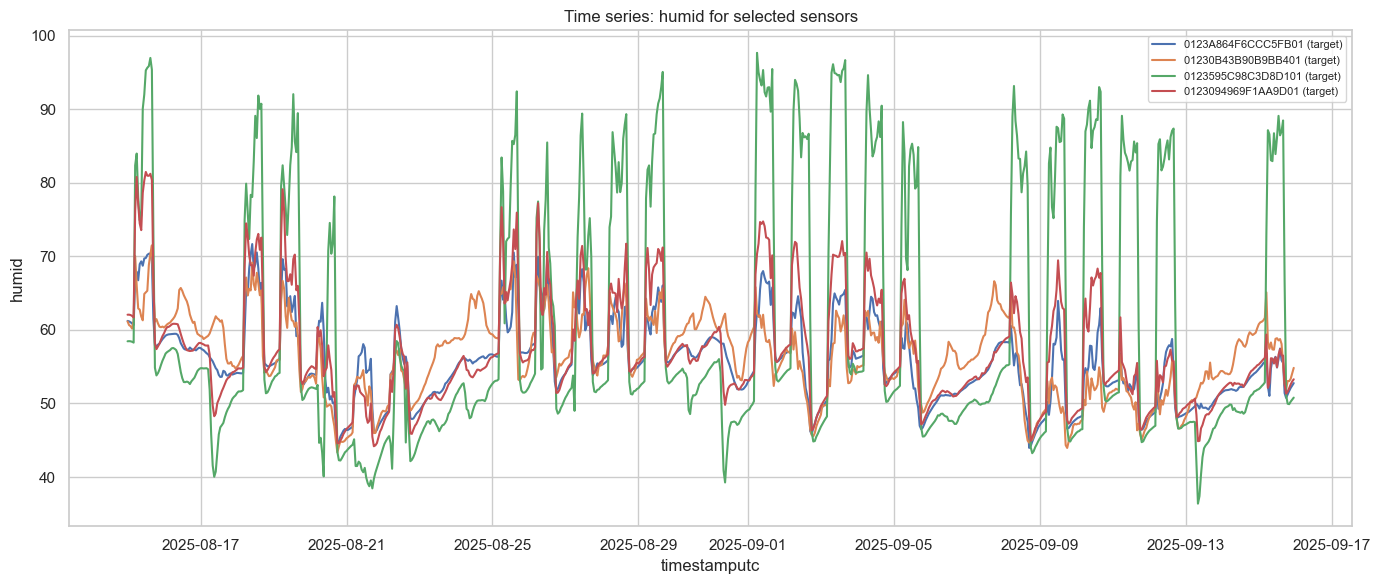

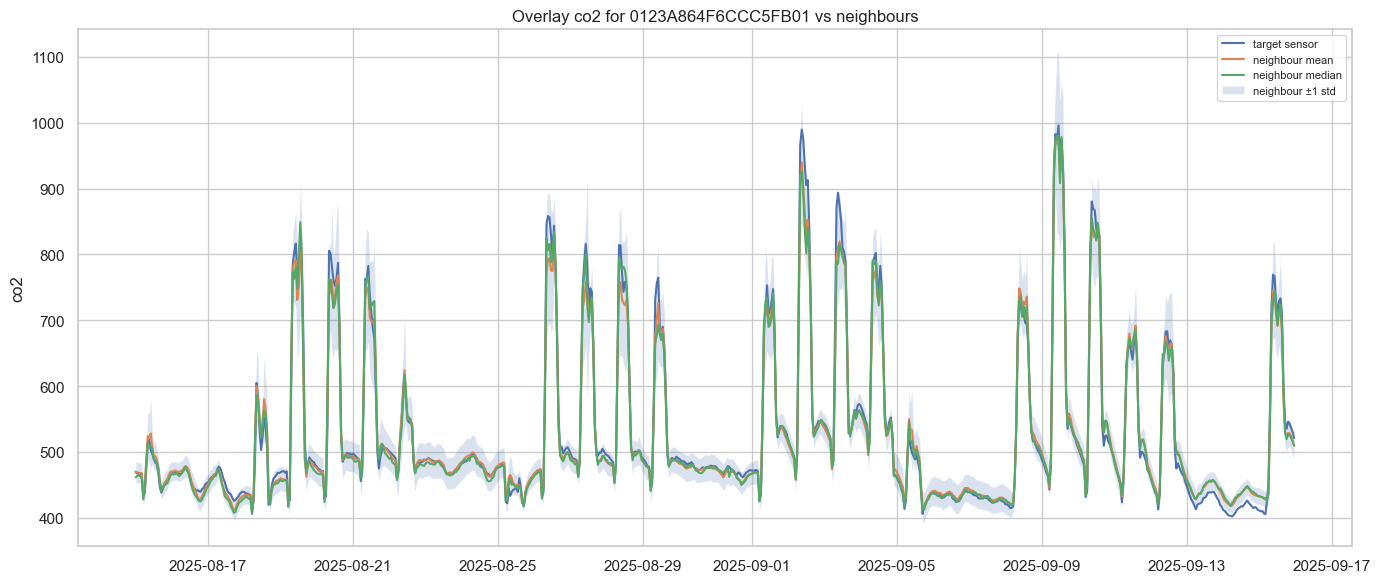

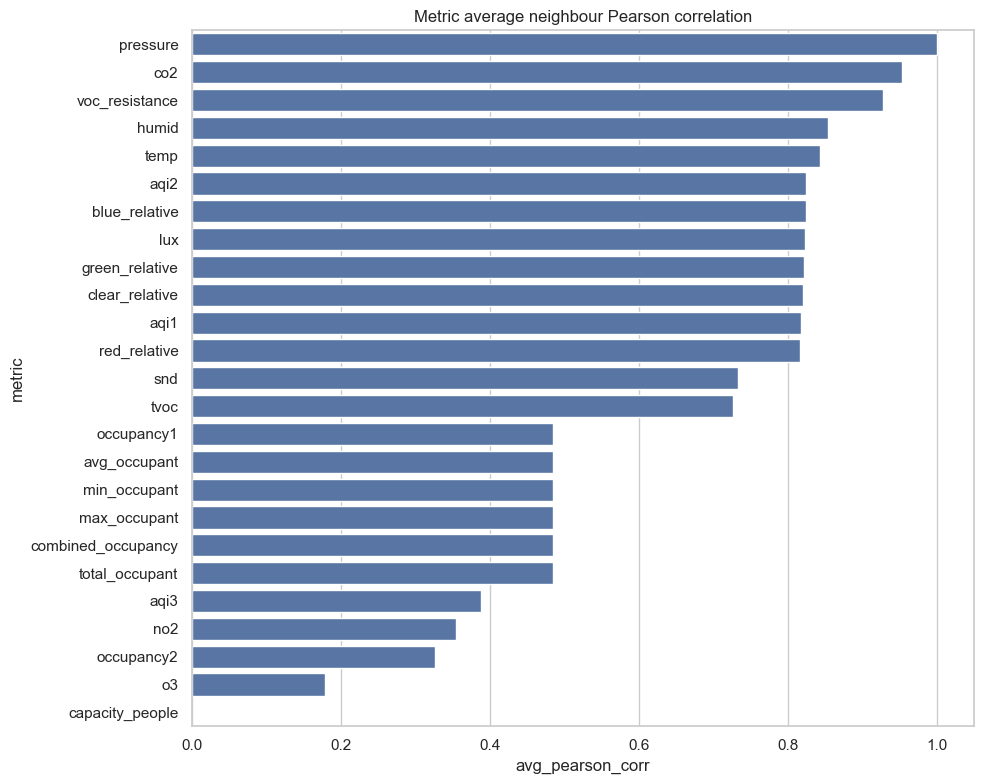

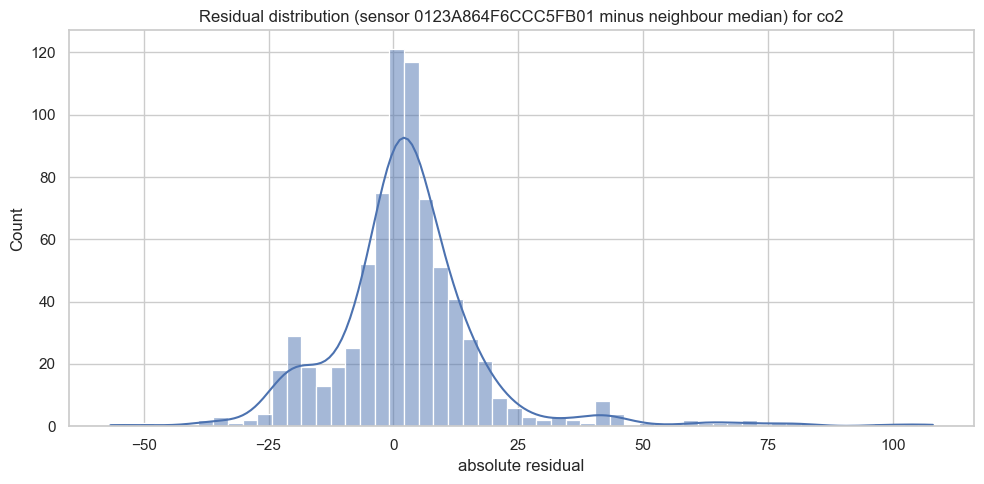

/var/folders/nn/cc_nydqj2_n5tddmw2qsf4800000gn/T/ipykernel_63161/1594597831.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(coverage_agg_sorted['sensor'][:20], rotation=90, fontsize=8)


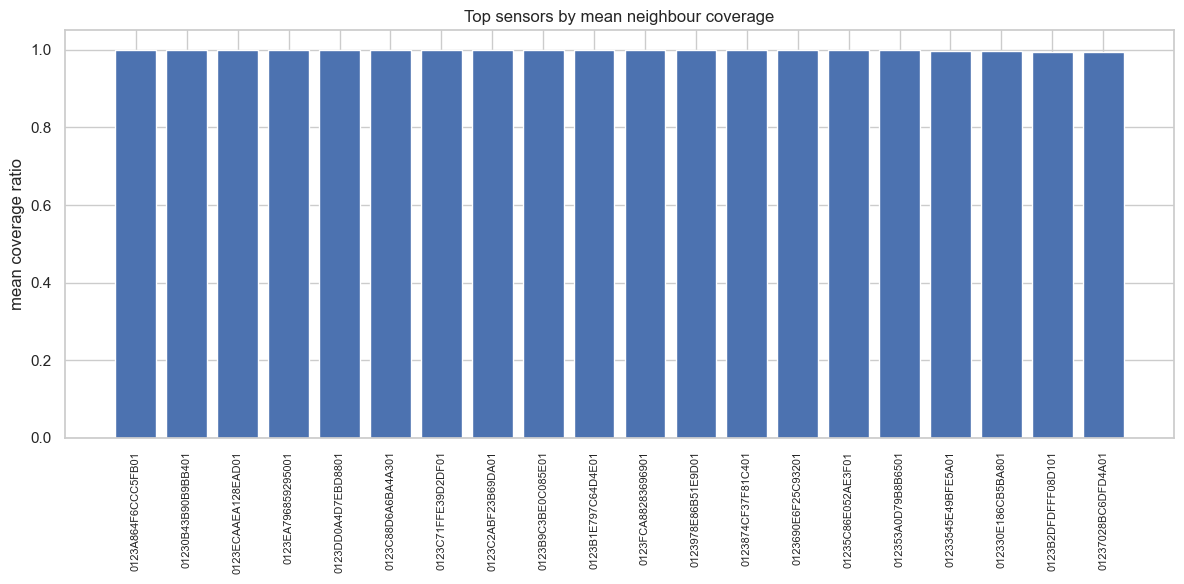

In [20]:
# 5. Visual diagnostics
# Plot a 12-month sample for selected sensors
rich_sensors = coverage_agg.sort_values('mean_coverage', ascending=False).head(2)['sensor'].tolist()
poor_sensors = coverage_agg.sort_values('mean_coverage', ascending=True).head(2)['sensor'].tolist()

chosen_sensors = rich_sensors + poor_sensors
# chosen_metrics = metrics[:3]
chosen_metrics = metrics[5:12]
print('Chosen metrics for diagnostics:', chosen_metrics)

for metric in chosen_metrics:
    mdf = wide_metric[metric]
    fig, ax = plt.subplots(figsize=(14, 6))
    for sensor in chosen_sensors:
        if sensor not in mdf.columns:
            continue
        ax.plot(mdf.index, mdf[sensor], label=f'{sensor} (target)')

    ax.set_title(f'Time series: {metric} for selected sensors')
    ax.set_xlabel('timestamputc')
    ax.set_ylabel(metric)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

# Overlay for one sample sensor with neighbour mean/median for first chosen metric
if chosen_sensors and chosen_metrics:
    sensor = chosen_sensors[0]
    metric = chosen_metrics[0]
    mdf = wide_metric[metric]
    neighs = [n for n in neighbour_map.get(sensor, []) if n in sensor_list]
    if neighs:
        df_overlay = pd.DataFrame({
            'sensor': mdf[sensor],
            'neigh_mean': mdf[neighs].mean(axis=1),
            'neigh_median': mdf[neighs].median(axis=1),
            'neigh_std': mdf[neighs].std(axis=1)
        })
        df_overlay['upper'] = df_overlay['neigh_mean'] + df_overlay['neigh_std']
        df_overlay['lower'] = df_overlay['neigh_mean'] - df_overlay['neigh_std']

        fig, ax = plt.subplots(figsize=(14, 6))
        ax.plot(df_overlay.index, df_overlay['sensor'], label='target sensor')
        ax.plot(df_overlay.index, df_overlay['neigh_mean'], label='neighbour mean')
        ax.plot(df_overlay.index, df_overlay['neigh_median'], label='neighbour median')
        ax.fill_between(df_overlay.index, df_overlay['lower'], df_overlay['upper'], alpha=0.2, label='neighbour ±1 std')
        ax.set_title(f'Overlay {metric} for {sensor} vs neighbours')
        ax.set_ylabel(metric)
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

# Heatmap of metric pearson correlations
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=coherence_df.sort_values('avg_pearson_corr', ascending=False), x='avg_pearson_corr', y='metric', ax=ax)
ax.set_title('Metric average neighbour Pearson correlation')
plt.tight_layout()
plt.show()

# Residual distribution for one metric
if chosen_metrics:
    metric = chosen_metrics[0]
    mdf = wide_metric[metric]
    sensor = chosen_sensors[0]
    neighs = [n for n in neighbour_map.get(sensor, []) if n in sensor_list]
    if neighs:
        resid = (mdf[sensor] - mdf[neighs].median(axis=1)).dropna()
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.histplot(resid, kde=True, ax=ax)
        ax.set_title(f'Residual distribution (sensor {sensor} minus neighbour median) for {metric}')
        ax.set_xlabel('absolute residual')
        plt.tight_layout()
        plt.show()

# coverage plot
fig, ax = plt.subplots(figsize=(12, 6))
coverage_agg_sorted = coverage_agg.sort_values('mean_coverage', ascending=False)
ax.bar(coverage_agg_sorted['sensor'][:20], coverage_agg_sorted['mean_coverage'][:20])
ax.set_xticklabels(coverage_agg_sorted['sensor'][:20], rotation=90, fontsize=8)
ax.set_title('Top sensors by mean neighbour coverage')
ax.set_ylabel('mean coverage ratio')
plt.tight_layout()
plt.show()

## 6. Verdict Table & Interpretation

The `metric_neighbour_coherence.csv` table provides a ranked metric-level view.

- `avg_pearson_corr` and `avg_spearman_corr` indicate direct neighbour similarity.
- `mean_abs_resid` and `median_abs_resid` show baseline coherence error.
- `stability_rank` (1 = best) simplifies metric prioritisation.
- `usable_for_neighbour_monitoring` is a first-pass decision (yes/review/no).

### Next recommended actions

1. Review metrics with `usable_for_neighbour_monitoring` = yes for residual model prototypes.
2. Investigate metrics flagged `review` for temporal nonlinearity or higher noise.
3. If coverage is low for key sensors, plan fallback to self-history only.
4. For strongly correlated metrics, test target-minus-neighbour residual drift endpoints.